# About this Continuous Assessment
|  |  |
|--|--|
|Assessment| 8|
|Delivery method | Canvas submission of this file after completion |
|Deadline | As specified on Canvas. |
|ILOs|Be able to implement a dynamic model and analyze the motion of multi-degree-of-freedom (DoF) robotic manipulators.|

# Allowed packages 
Do not modify these. Do not add or remove packages.

In [15]:
# Helper functions and packages
%pip install numpy
%pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Allowed imports

<div class="alert alert-block alert-info">
Do not modify, add, or remove imports. Do not add imports anywhere else in this notebook.
</div>

In [16]:
# Helper functions and packages
import numpy as np
import matplotlib.pyplot as plt


## Instructions
This assessment is made of 2 tasks. There are two points in total for this part of the assessment.   
Each cell is tagged for the assessment, so do not delete or otherwise tamper with the cells. The assignment is to add content to each of the Python cells as requested.

## Verify the spreadsheet

Your student ID will be used to assign you parameters. For each task, look into your row to see what you must implement.

# Dynamics of a 2-DoF Planar Manipulator

Consider the planar manipulator equipped with two revolute joints as depicted. 
- The joint angles are denoted by $q_i$, where $i = 1, 2$, and serve as the generalized coordinates. 
- The mass of link $i$ is represented by $m_i$, while $l_i$ indicates the length of link $i$. 
- The distance from the preceding joint to the center of mass of link $i$ is denoted by $l_{ci}$, and 
- The moment of inertia of link $i$ about an axis perpendicular to the page is $I_i$, passing through the center of mass of link $i$.


  <figure style="margin: 10px; width: 100%; text-align: left;">
    <img src="figures/figure1.png" alt='A single-link robot arm.' style="max-width: 100%; height: 250px;"/>
    <figcaption>Figure 1 - A 2-DoF Planar Manipulator.</figcaption>
  </figure>


The equations of motion of the manipulator can be written as: $D(q)\ddot{q} + C(q,\dot{q})\dot{q} + G(q) = \tau $  
where the inertial matrix $D(q) = \begin{pmatrix} d_{11} & d_{12} \\ d_{21} & d_{22}  \end{pmatrix}$, while the components of inertial matrix are given as:    
$d_{11} = m_1 l_{c1}^2+m_2(l_1^2+l_{c2}^2+2l_1l_{c2}\cos{q_2})+I_1+I_2$,  
$d_{12} = d_{21} = m_2(l_{c2}^2+l_1l_{c2}\cos{q_2})+I_2$,  
$d_{22} = m_2 l_{c2}^2+I_2$. 

The Coriolis torque   
$C(q,\dot{q})\dot{q} = \begin{pmatrix} h(2\dot{q}_1+\dot{q}_2)\dot{q}_2 \\ -h\dot{q}_1^2 \end{pmatrix}$,  $h = -m_2l_1 l_{c2} \sin{q_2}$.  
The gravity torque   
$G(q) = \begin{pmatrix} (m_1 l_{c1}+m_2l_1)g\cos{q_1}+m_2l_{c2}g\cos{(q_1+q_2)}\\m_2l_{c2}g\cos{(q_1+q_2)}  \end{pmatrix}$. 

Please enter the parameters associated with your ID for the dynamics model, as listed in the spreadsheet.

After that, implement the equations of motion and analyse the manipulator behaviour under specific torque inputs in Tasks 1 and 2. 

In [17]:
# Define Parameters for Tasks 1 and 2
############################################################
# TODO:   
# Enter the parameters below (Find them in the spreadsheet)
model_parameters = {
    'm1': 1.53,    # mass of link 1
    'm2': 1.58,    # mass of link 2
    'l1': 0.42,    # length of link 1
    'l2': 0.38,    # length of link 2
    'lc1': 0.21,   # distance from preceding joint to the centre of mass of link 1
    'lc2': 0.19,   # distance from preceding joint to the centre of mass of link 2
    'I1': 0.028,    # inertia of link 1, kg m^2
    'I2': 0.03,    # inertia of link 2, kg m^2
    'g': 9.8,     # gravity acceleration 
}
############################################################


In [18]:
# Define initial joint angles
################################################################################
# TODO:   
# Enter the initial joint angles below (Find them in the spreadsheet)
# The angles are given in degrees, convert them into radians 
q1_0 = np.radians(25)          # initial angle of joint 1
q2_0 = np.radians(20)          # initial angle of joint 2
q1_dot_0 = 0      # initial angular velocity of joint 1
q2_dot_0 = 0      # initial angular velocity of joint 2
################################################################################


---
## ✏️ Task 1 - Inertial matrix
Please complete the following function to calculate the inertial matrix in the dynamics model at the initial angles and angular velocities (1 pt). 

In [19]:
# Code for Task 1

# Inertial matrix
def Inertial_Matrix(q1, q2, params): 
    '''
    Inputs:
        q1, q2 are scalars, representing the joint angle in radian
        params is a dictionary with dynamic model parameters
    Output:
        D is a 2x2 2D array, representing the inertial matrix
    '''
    # Input necessary parameters as needed
    m1 = params.get('m1')
    m2 = params.get('m2')
    I1 = params.get('I1')
    I2 = params.get('I2')
    l1 = params.get('l1')
    lc1 = params.get('lc1')
    lc2 = params.get('lc2')
    #######################################################################
    # TODO:    
    d11 = m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(q2)) + I1 + I2
    d12 = m2 * (lc2**2 + l1 * lc2 * np.cos(q2)) + I2
    d21 = d12
    d22 = m2 * lc2**2 + I2

    D = np.array([[d11, d12],
                  [d21, d22]])
    #######################################################################

    return D

D_0 = Inertial_Matrix(q1_0, q2_0, model_parameters)
print(D_0)
# Marking variables (don't modify)
ansT1 = D_0

# End of code for Task 1

[[0.69818341 0.2055182 ]
 [0.2055182  0.087038  ]]


In [20]:
## DON'T MODIFY ANY CODE IN THIS CELL 

# Coriolis and centrifugal torque
def coriolis(q1,q2, q1_dot, q2_dot, params):
    '''
    Inputs:
        q1, q2 are scalars, representing the joint angles in radian
        q1_dot, q2_dot are scalars, representing the joint angular velocities in radian
        params is a dictionary including all system parameters
    Output:
        C is a 1D array with 2 elements
    '''
    # Input necessary parameters as needed
    m2 = params.get('m2')
    l1 = params.get('l1')
    lc2 = params.get('lc2')  
    
    C = np.zeros(2)  # Creates a 1D array with 2 elements, initialized to 0
  
    s2 = np.sin(q2)  
    h = -m2 * l1 * lc2 * s2
    p1 = h  
    p2 = -h  
    C = np.zeros(2)  # Creates a 1D array with 2 elements, initialized to 0
    C[0] = p1 * (q2_dot**2 + 2 * q1_dot * q2_dot)
    C[1] = p2 * q1_dot**2
    return C

# Gravity torque
def gravity(q1,q2,params):
    '''
    Inputs:
        q1, q2 are scalars, representing the joint angle in radian
        params is a dictionary including all system parameters
    Output:
        G is a 1D array with 2 elements
    '''
    # Input necessary parameters as needed
    m1 = params.get('m1')
    m2 = params.get('m2')  
    l1 = params.get('l1')
    lc1 = params.get('lc1')
    lc2 = params.get('lc2')
    g = params.get('g')
         
    G = np.zeros(2)  # Creates a 1D array with 2 elements, initialized to 0

    c1 = np.cos(q1) 
    c12 = np.cos(q1+q2)
    G[0] = (m1*lc1+ m2*l1)*g*c1 + m2*lc2*g*c12
    G[1] = m2*lc2*g*c12   
    return G


---
## ✏️ Task 2 -  Analyse system response
Suppose that there are the following joint torques: 
- The first joint is stimulated by $\tau_1 (t) = -0.1\dot{q}_1, 0s \leq t \leq 20s$.
- The sencond link is subjected to a stimulus  
$
\tau_2(t) = \left\{\begin{matrix} 0.02 - 0.1 \dot{q}_2(t), \quad  0s \leq t< 2s\\ -0.1\dot{q}_2 (t),\quad \qquad 2s \leq t \leq 20s  \end{matrix} \right.
$

Simulate the joint angles $q_1(t)$ and $q_2(t)$, starting at the initial angles and angular velocities previously defined, and record the evolution of $q_1(t)$ and $q_2(t)$ using a sample time $0.01 s$.  (1 pt)

In [21]:
## DON'T MODIFY ANY CODE IN THIS CELL 
# Numerical integration 
def UpdateAngle(q, qdot, dt):
    return np.array([q[0] + dt * qdot[0], 
                     q[1] + dt * qdot[1]])

def UpdateVel(qdot, qddot, dt):
    return np.array([qdot[0] + dt * qddot[0], 
                     qdot[1] + dt * qddot[1]])

# Joint acceleration
def JointAccel(Torque, D, Cqdot, G):
    '''
    Inputs:
        Torque, Cqdot, G are 1D array with 2 elements
        D is a 2x2 2D array
    Output:
        qddot is a 1D array with 2 elements, 
        representing the joint angular acceleration of both joints
    '''
    qddot =  np.linalg.inv(D) @ (Torque - Cqdot- G)    
    return qddot    

In [22]:
# Code for Task 2
# Define sampling rate
dt = 0.01  # Define here the sampling rate

# Define movement duration
T = 20  # Define here the movement duration
T_samples = int(T / dt)

# Initial joint angles
q_start = np.array([q1_0, q2_0])  

# Initialize q with zeros and set the first row to q_start
q = np.zeros((T_samples, 2))
q[0, :] = q_start

# Initialize qdot with zeros and set the first row to [0, 0]
qdot = np.zeros((T_samples, 2))

# Initialize acceleration array for dynamics calculation
qddot = np.zeros((T_samples, 2))

for i in range(T_samples - 1): 
    t = (i + 1) * dt  # current time
    #######################################################################
    # TODO:
    # Define joint torques here as a numpy array
    if t < 2:
        tau2 = 0.02 - 0.1 * qdot[i, 1]
    else:
        tau2 = -0.1 * qdot[i, 1]

    tau1 = -0.1 * qdot[i, 0]

    Torque = np.array([tau1, tau2])
    #######################################################################

    # Compute Dynamics
    D = Inertial_Matrix(q[i, 0], q[i, 1], model_parameters)
    Cqdot = coriolis(q[i, 0],q[i, 1], qdot[i, 0], qdot[i, 1], model_parameters)
    G = gravity(q[i,0],q[i,1],model_parameters)
    qddot[i+1, :] = JointAccel(Torque, D, Cqdot, G)

    # Movement integration
    qdot[i + 1, :] = UpdateVel(qdot[i, :], qddot[i+1, :], dt)  
    q[i + 1, :] = UpdateAngle(q[i, :], qdot[i + 1, :], dt)   


# Marking variables (don't modify)
ansT2_q = q
ansT2_q_dot = qdot

# End of code for Task 2

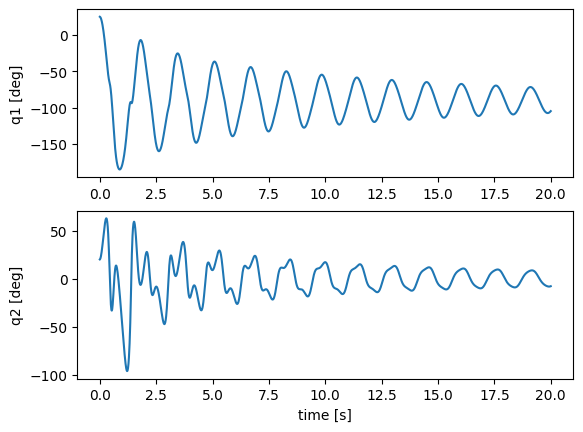

In [23]:
time = np.linspace(0,T,q.shape[0])
plt.figure()
plt.subplot(211)
plt.plot(time, q[:,0]*180/np.pi)
plt.ylabel('q1 [deg]')
plt.subplot(212)
plt.ylabel('q2 [deg]')
plt.xlabel('time [s]')
plt.plot(time,q[:,1]*180/np.pi)
plt.show()